In [ ]:
import re
import requests
from bs4 import BeautifulSoup

In [10]:
headers = {
    "User-Agent":"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36 OPR/109.0.0.0"
}

In [11]:
from datetime import datetime
import matplotlib.pyplot as plt
def plot_market_value_hist(response, player_name):
  data = response.json()

  timestamps = [point['x'] for point in data['list']]
  market_values = [point['y'] for point in data['list']]
  labels = [point['datum_mw'] for point in data['list']]
  clubs = [point['verein'] for point in data['list']]
  ages = [point['age'] for point in data['list']]

  dates = [datetime.fromtimestamp(ts / 1000) for ts in timestamps]

  plt.figure(figsize=(12, 6))
  plt.plot(dates, market_values, marker='o', linestyle='-', color='b')

  for i, label in enumerate(labels):
      plt.annotate(f"{clubs[i]} - {ages[i]}", (dates[i], market_values[i]), textcoords="offset points", xytext=(0, 10), ha='center')

  plt.xlabel('Date')
  plt.ylabel('Market Value (€)')
  plt.title(f'Market Value Development for {player_name}')
  plt.xticks(rotation=45)
  plt.grid(True)

  plt.tight_layout()
  plt.show()

In [ ]:
def extract_date(input_string):
    # Expresión regular para encontrar la fecha después de "Last update:"
    pattern = r"Last update:\s+([A-Za-z]+\s+\d{1,2},\s+\d{4})"
    match = re.search(pattern, input_string)
    if match:
        date = match.group(1)
        return date
    else:
        return None

In [15]:
import numpy as np
player_names =[]
player_values = []
player_contract_expiry_dates = []
market_value_last_update = []
dates = []
counter = 0
def get_player_info(url):
  global counter
  player_id = url.split('/')[-1]
  response = requests.get(url,headers=headers)
  if int(response.status_code) == 200:
    soup = BeautifulSoup(response.content, "html.parser")
    player_name = soup.select_one('h1[class="data-header__headline-wrapper"]').text.split('\n')[-1].strip()
    player_contract_expiry = re.search("Contract expires: (.*)", soup.text)
    if player_contract_expiry != None:
      player_contract_expiry = player_contract_expiry.group(1)
    else:
      player_contract_expiry = np.nan
    market_value = re.search("€(.*)",soup.text).group(0).split(" ")[0]
    market_value_date=re.search("€(.*)",soup.text).group(0)
    response = requests.get(
      f'https://www.transfermarkt.us/ceapi/marketValueDevelopment/graph/{player_id}',
      headers=headers
    )
    last_update_MV = extract_date(market_value_date)
    market_value_last_update.append(last_update_MV)
    player_names.append(player_name)
    player_values.append(market_value)
    player_contract_expiry_dates.append(player_contract_expiry)
    current_timestamp = datetime.now()
    date = current_timestamp.strftime('%Y-%m-%d')
    dates.append(date)
    print(f"Player name: {player_name}")
    if counter < 10:
      plot_market_value_hist(response, player_name)
      counter += 1

    print(f"Current market value: {market_value}")
    print(f"Contract expiry date: {player_contract_expiry}")
  else:
    print("Hubo un error al intentar obtener los datos del jugador.")

Player name: Kylian Mbappé


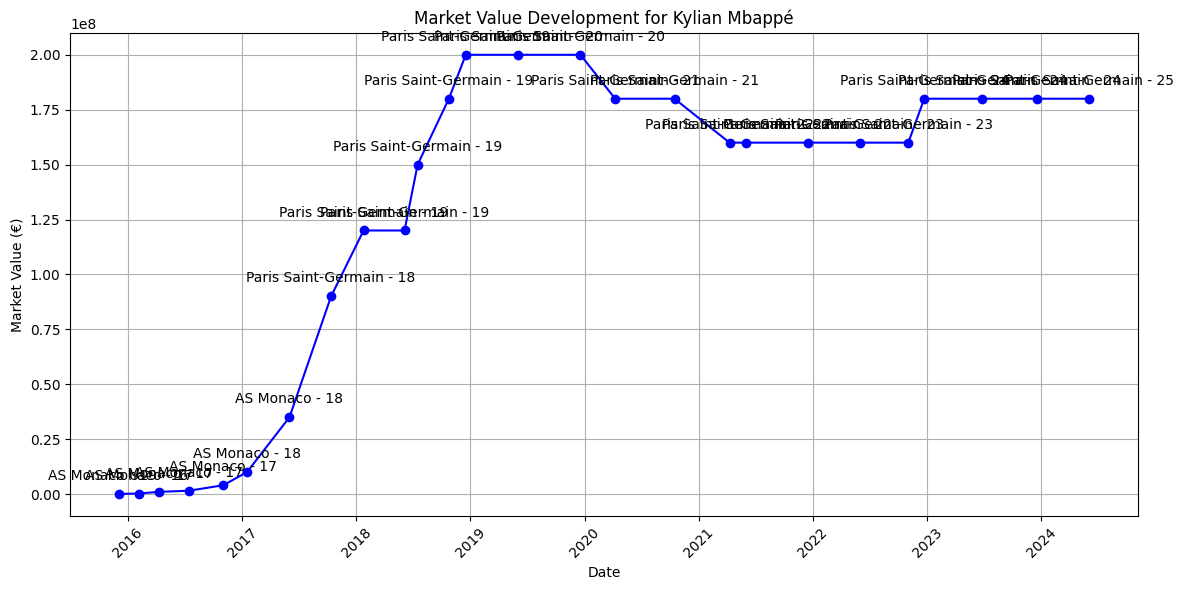

Current market value: €180.00m
Contract expiry date: Jun 30, 2029
Player name: Gianluigi Donnarumma


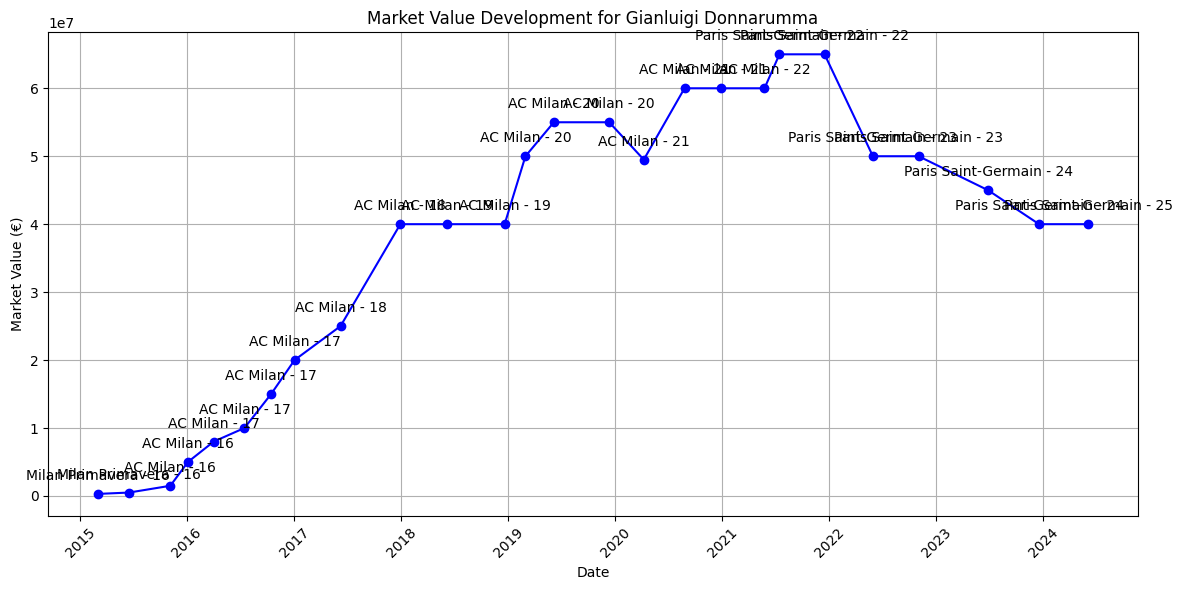

Current market value: €40.00m
Contract expiry date: Jun 30, 2026
Player name: Erling Haaland


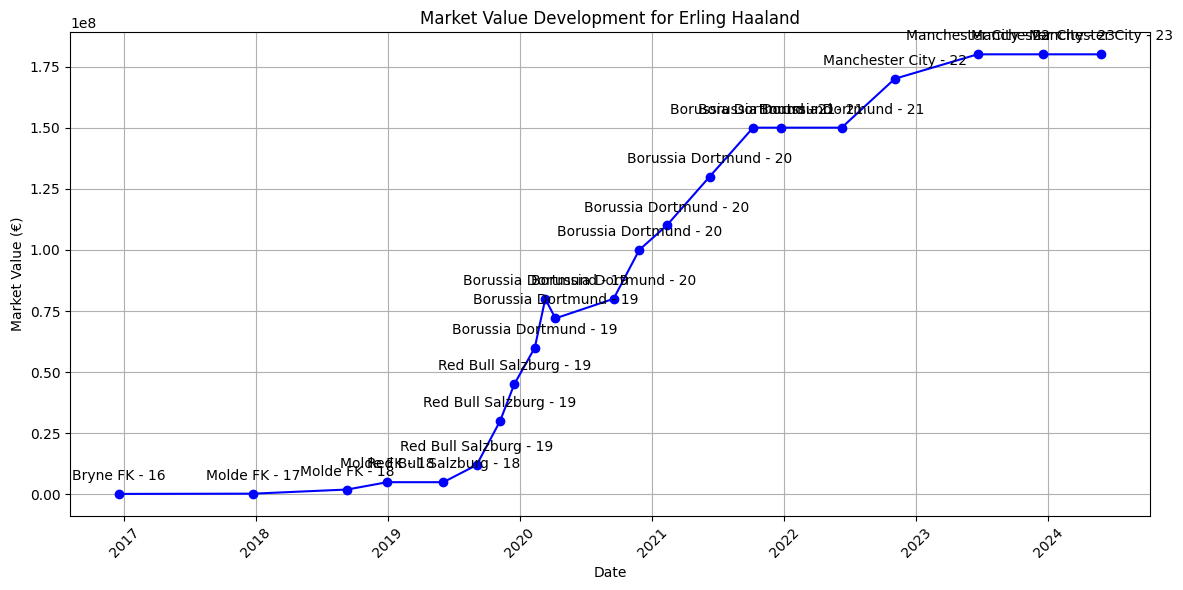

Current market value: €180.00m
Contract expiry date: Jun 30, 2027
Player name: Jadon Sancho


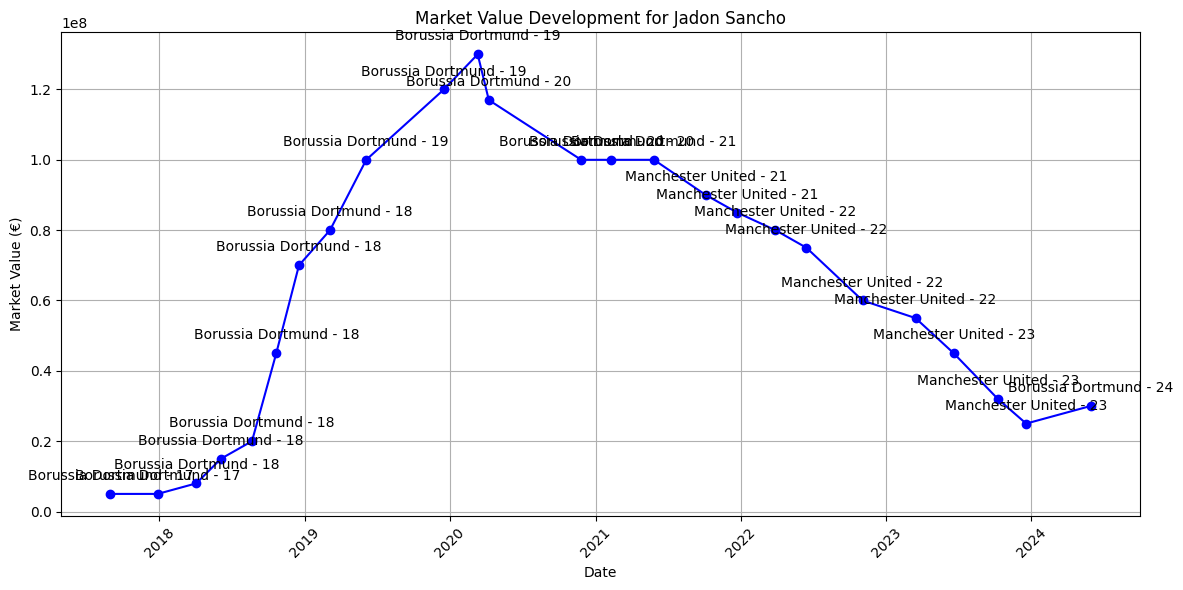

Current market value: €30.00m
Contract expiry date: Jun 30, 2026
Player name: Kai Havertz


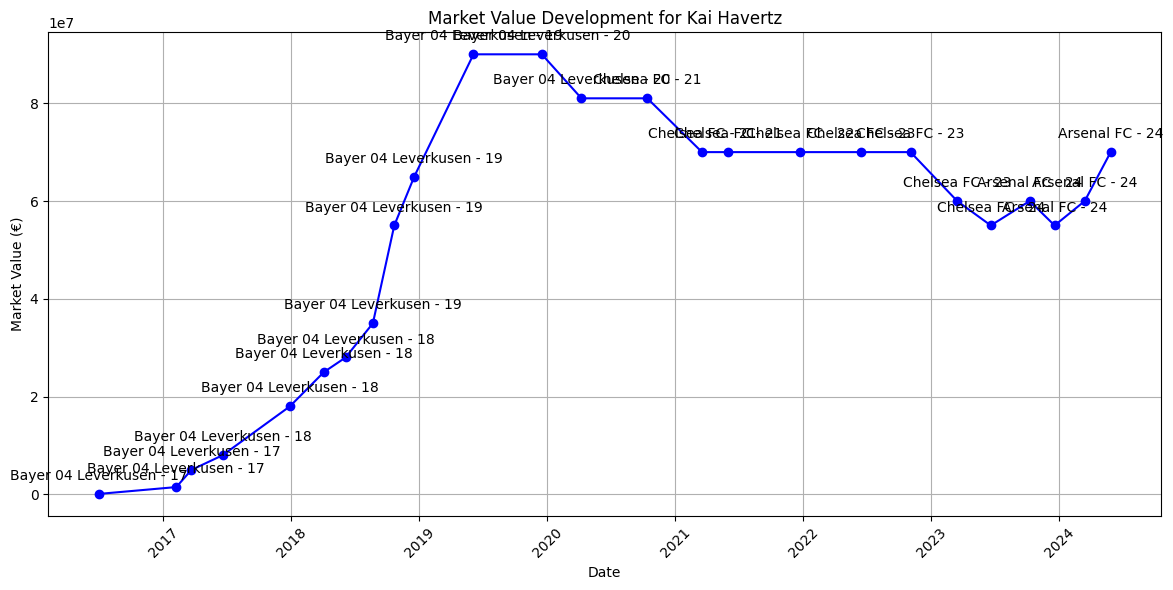

Current market value: €70.00m
Contract expiry date: Jun 30, 2028
Player name: Matthijs de Ligt


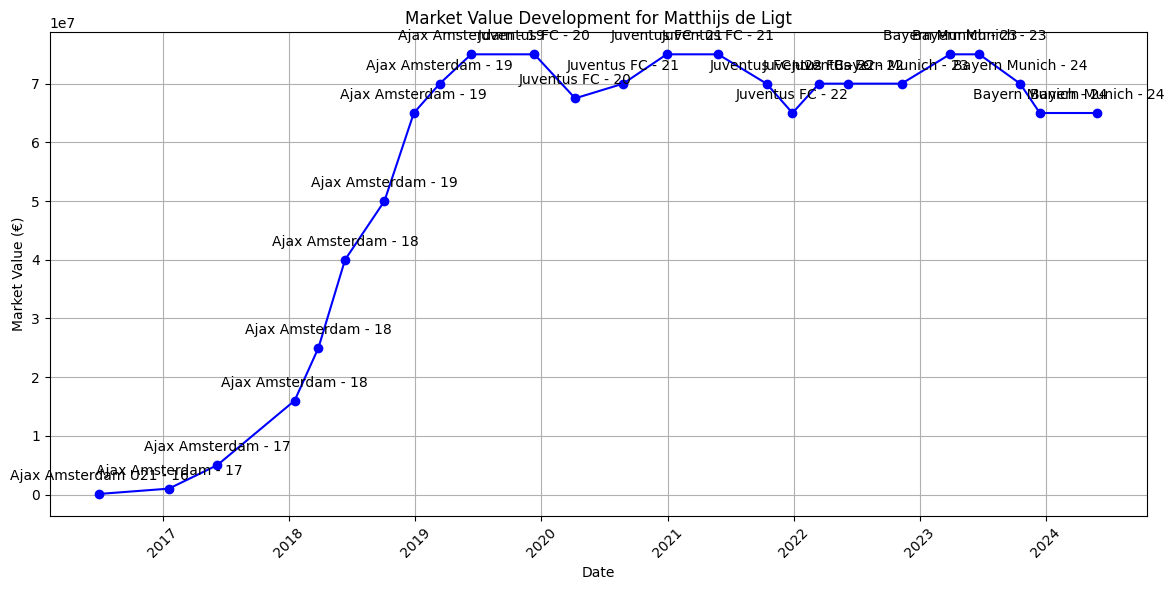

Current market value: €65.00m
Contract expiry date: Jun 30, 2027
Player name: Pedri


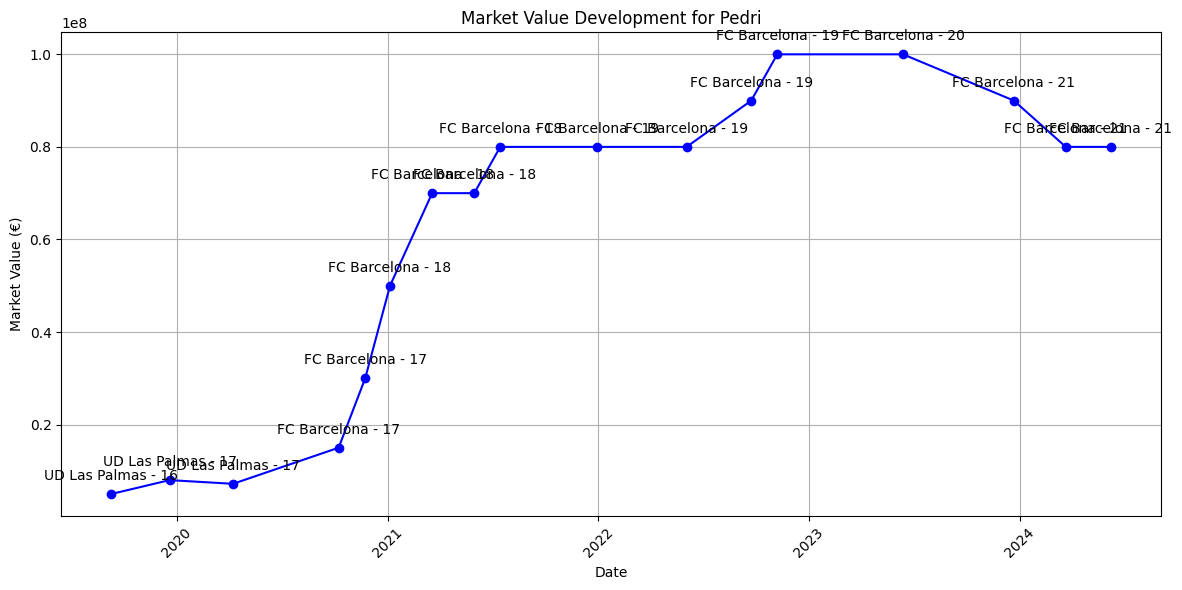

Current market value: €80.00m
Contract expiry date: Jun 30, 2026
Player name: João Félix


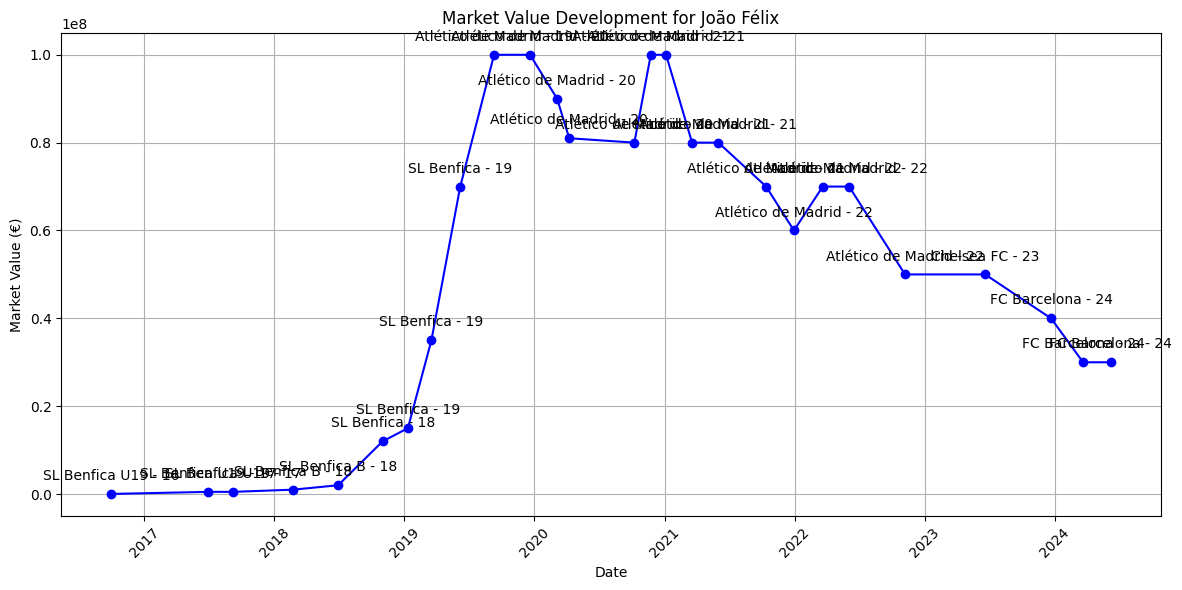

Current market value: €30.00m
Contract expiry date: Jun 30, 2029
Player name: Vinicius Junior


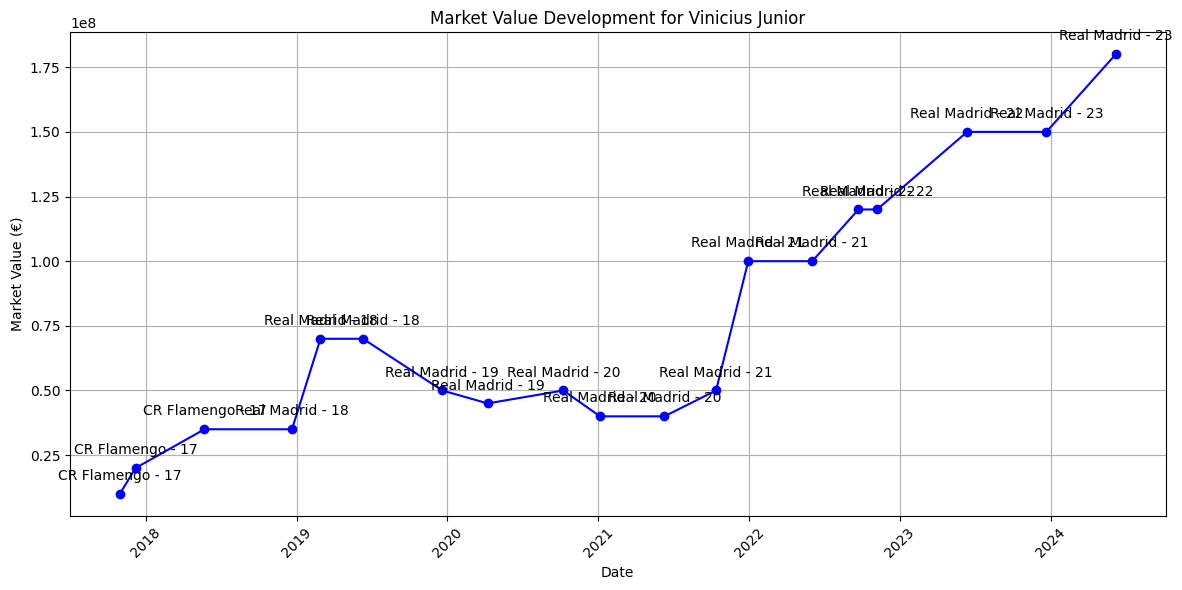

Current market value: €180.00m
Contract expiry date: Jun 30, 2027
Player name: Jamal Musiala


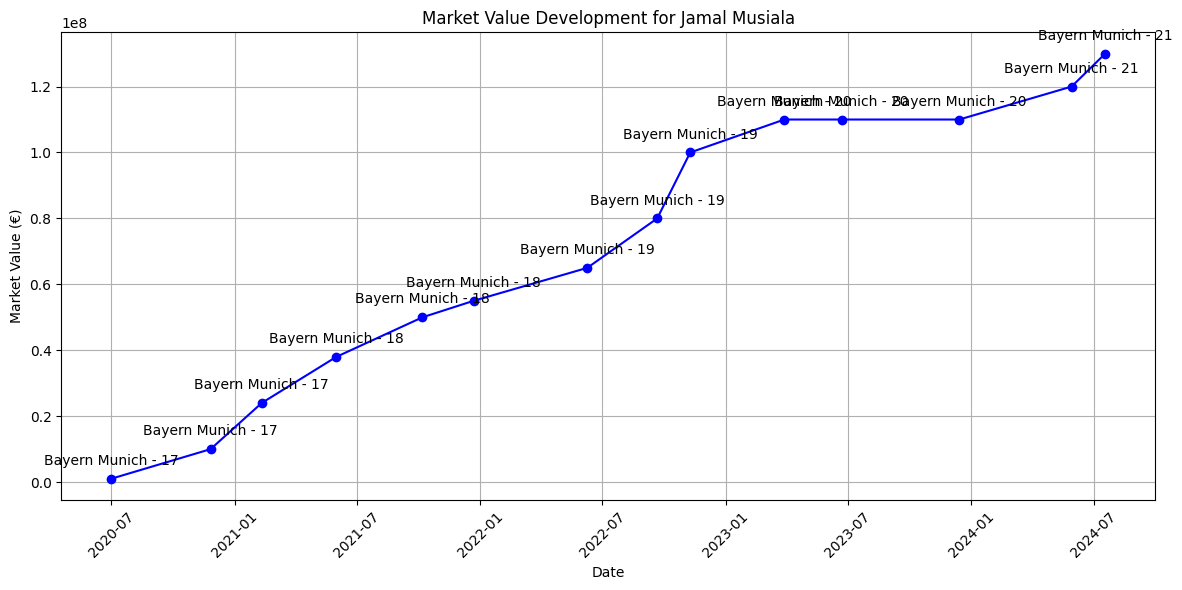

Current market value: €130.00m
Contract expiry date: Jun 30, 2026
Player name: Phil Foden
Current market value: €150.00m
Contract expiry date: Jun 30, 2027
Player name: Gabriel Jesus
Current market value: €65.00m
Contract expiry date: Jun 30, 2027
Player name: Ousmane Dembélé
Current market value: €60.00m
Contract expiry date: Jun 30, 2028
Player name: Sandro Tonali
Current market value: €38.00m
Contract expiry date: Jun 30, 2028
Player name: Alban Lafont
Current market value: €9.00m
Contract expiry date: Jun 30, 2027
Player name: Rodrygo
Current market value: €110.00m
Contract expiry date: Jun 30, 2028
Player name: Trincão
Current market value: €20.00m
Contract expiry date: Jun 30, 2026
Player name: Leroy Sané
Current market value: €70.00m
Contract expiry date: Jun 30, 2025
Player name: Dele Alli
Current market value: €5.00m
Contract expiry date: nan
Player name: Jude Bellingham
Current market value: €180.00m
Contract expiry date: Jun 30, 2029
Player name: Alen Halilovic
Current marke

In [ ]:
urls = [
    "https://www.transfermarkt.com/kylian-mbappe/profil/spieler/342229",
    "https://www.transfermarkt.com/gianluigi-donnarumma/profil/spieler/315858",
    "https://www.transfermarkt.com/erling-haaland/profil/spieler/418560",
    "https://www.transfermarkt.com/jadon-sancho/profil/spieler/401173",
    "https://www.transfermarkt.com/kai-havertz/profil/spieler/309400",
    "https://www.transfermarkt.com/matthijs-de-ligt/profil/spieler/326031",
    "https://www.transfermarkt.com/pedri/profil/spieler/683840",
    "https://www.transfermarkt.com/joao-felix/profil/spieler/462250",
    "https://www.transfermarkt.com/vinicius-junior/profil/spieler/371998",
    "https://www.transfermarkt.com/jamal-musiala/profil/spieler/580195",
    "https://www.transfermarkt.com/phil-foden/profil/spieler/406635",
    "https://www.transfermarkt.com/gabriel-jesus/profil/spieler/363205",
    "https://www.transfermarkt.com/ousmane-dembele/profil/spieler/288230",
    "https://www.transfermarkt.com/sandro-tonali/profil/spieler/397033",
    "https://www.transfermarkt.com/alban-lafont/profil/spieler/357117",
    "https://www.transfermarkt.com/rodrygo/profil/spieler/412363",
    "https://www.transfermarkt.com/trincao/profil/spieler/412669",
    "https://www.transfermarkt.com/leroy-sane/profil/spieler/192565",
    "https://www.transfermarkt.com/dele-alli/profil/spieler/207929",
    "https://www.transfermarkt.com/jude-bellingham/profil/spieler/581678",
    "https://www.transfermarkt.com/alen-halilovic/profil/spieler/226074",
    "https://www.transfermarkt.com/florian-wirtz/profil/spieler/598577",
    "https://www.transfermarkt.com/malcom/profil/spieler/323704",
    "https://www.transfermarkt.com/esequiel-barco/profil/spieler/456623",
    "https://www.transfermarkt.com/eduardo-camavinga/profil/spieler/640428",
    "https://www.transfermarkt.com/angel-gomes/profil/spieler/392770",
    "https://www.transfermarkt.com/trent-alexander-arnold/profil/spieler/314353",
    "https://www.transfermarkt.com/alberto-moleiro/profil/spieler/733576",
    "https://www.transfermarkt.com/mason-greenwood/profil/spieler/532826",
    "https://www.transfermarkt.com/youri-tielemans/profil/spieler/249565",
    "https://www.transfermarkt.com/ansu-fati/profil/spieler/466810",
    "https://www.transfermarkt.com/federico-valverde/profil/spieler/369081",
    "https://www.transfermarkt.com/renato-sanches/profil/spieler/258027",
    "https://www.transfermarkt.com/houssem-aouar/profil/spieler/395693",
    "https://www.transfermarkt.com/marcus-rashford/profil/spieler/258923",
    "https://www.transfermarkt.com/reinier/profil/spieler/627226",
    "https://www.transfermarkt.com/bukayo-saka/profil/spieler/433177",
    "https://www.transfermarkt.com/ryan-gravenberch/profil/spieler/478573",
    "https://www.transfermarkt.com/alphonso-davies/profil/spieler/424204",
    "https://www.transfermarkt.com/anthony-martial/profil/spieler/182877",
    "https://www.transfermarkt.com/nicolo-zaniolo/profil/spieler/392085",
    "https://www.transfermarkt.com/ferran-torres/profil/spieler/398184",
    "https://www.transfermarkt.com/moise-kean/profil/spieler/364135",
    "https://www.transfermarkt.com/callum-hudson-odoi/profil/spieler/392768",
    "https://www.transfermarkt.com/jesus-vallejo/profil/spieler/251896",
    "https://www.transfermarkt.com/gavi/profil/spieler/646740",
    "https://www.transfermarkt.com/mateo-kovacic/profil/spieler/51471",
    "https://www.transfermarkt.com/patrick-cutrone/profil/spieler/265078",
    "https://www.transfermarkt.com/dominik-szoboszlai/profil/spieler/451276",
    "https://www.transfermarkt.com/agustin-urzi/profil/spieler/636441",
    "https://www.transfermarkt.com/ousmane-dembele/profil/spieler/288230",
    "https://www.transfermarkt.com/lautaro-martinez/profil/spieler/406625",
    "https://www.transfermarkt.com/kelechi-iheanacho/profil/spieler/295330",
    "https://www.transfermarkt.com/christian-pulisic/profil/spieler/315779",
    "https://www.transfermarkt.com/dayot-upamecano/profil/spieler/344695",
    "https://www.transfermarkt.com/marco-asensio/profil/spieler/296622",
    "https://www.transfermarkt.com/lucas-paqueta/profil/spieler/444523",
    "https://www.transfermarkt.com/carles-alena/profil/spieler/284854",
    "https://www.transfermarkt.com/christos-tzolis/profil/spieler/451677",
    "https://www.transfermarkt.com/luke-shaw/profil/spieler/183288",
    "https://www.transfermarkt.com/thiago-almada/profil/spieler/576028",
    "https://www.transfermarkt.com/takefusa-kubo/profil/spieler/405398",
    "https://www.transfermarkt.com/fiete-arp/profil/spieler/343337",
    "https://www.transfermarkt.com/destiny-udogie/profil/spieler/556385",
    "https://www.transfermarkt.com/riqui-puig/profil/spieler/331511",
    "https://www.transfermarkt.com/christian-kouame/profil/spieler/337725",
    "https://www.transfermarkt.com/josko-gvardiol/profil/spieler/475959",
    "https://www.transfermarkt.com/leon-bailey/profil/spieler/387626",
    "https://www.transfermarkt.com/goncalo-guedes/profil/spieler/225122",
    "https://www.transfermarkt.com/youssoufa-moukoko/profil/spieler/467720",
    "https://www.transfermarkt.com/yann-karamoh/profil/spieler/324804"
]
for url in urls:
    get_player_info(url)


In [ ]:
import pandas as pd
dict = {'Name':player_names, 'Market Value':player_values, 'Contract Expiry Date': player_contract_expiry_dates, 'Last Update TM': market_value_last_update,'Date Logged':dates}
df = pd.DataFrame(dict)

In [ ]:
import pandas_gbq
pandas_gbq.to_gbq(
    df, 'football_players_market_value.MarketValueTransferMarkt', project_id='cif-bigdata', if_exists='append',
)

100%|██████████| 1/1 [00:00<00:00, 5940.94it/s]


Player name: George Ilenikhena


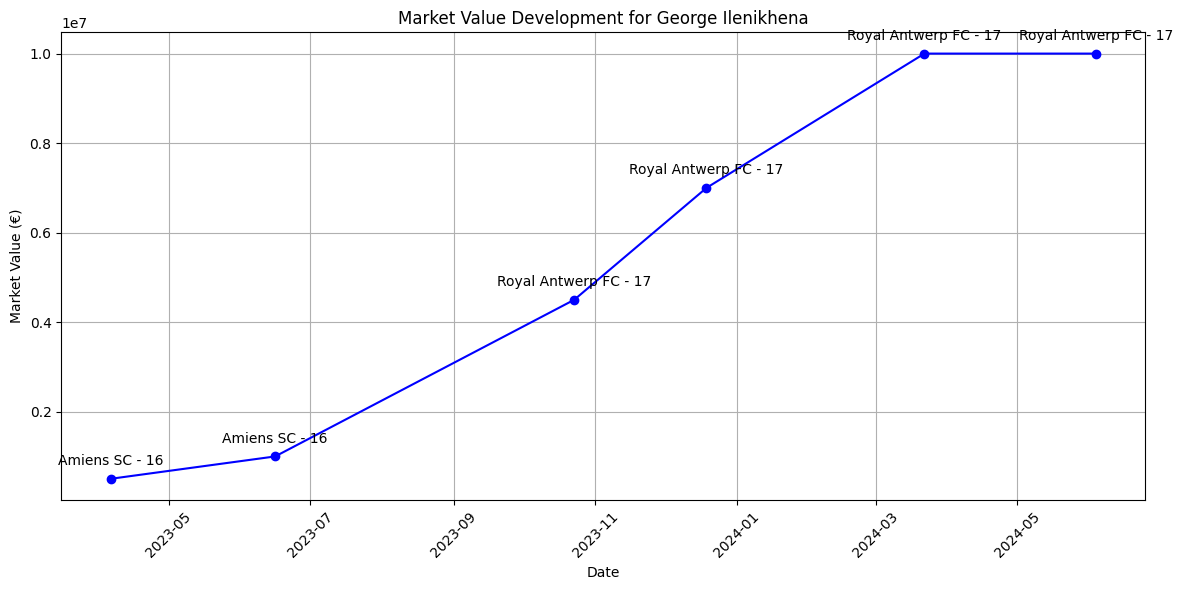

Current market value: €
Contract expiry date: nan
Player name: Guillaume Restes


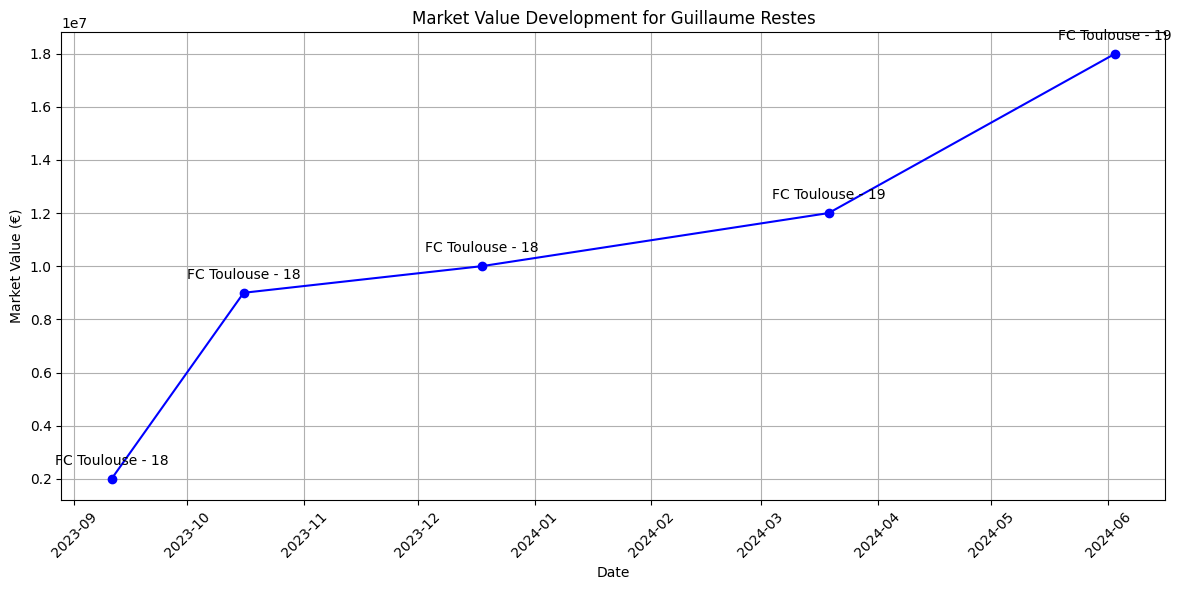

Current market value: €
Contract expiry date: nan
Player name: Francesco Camarda


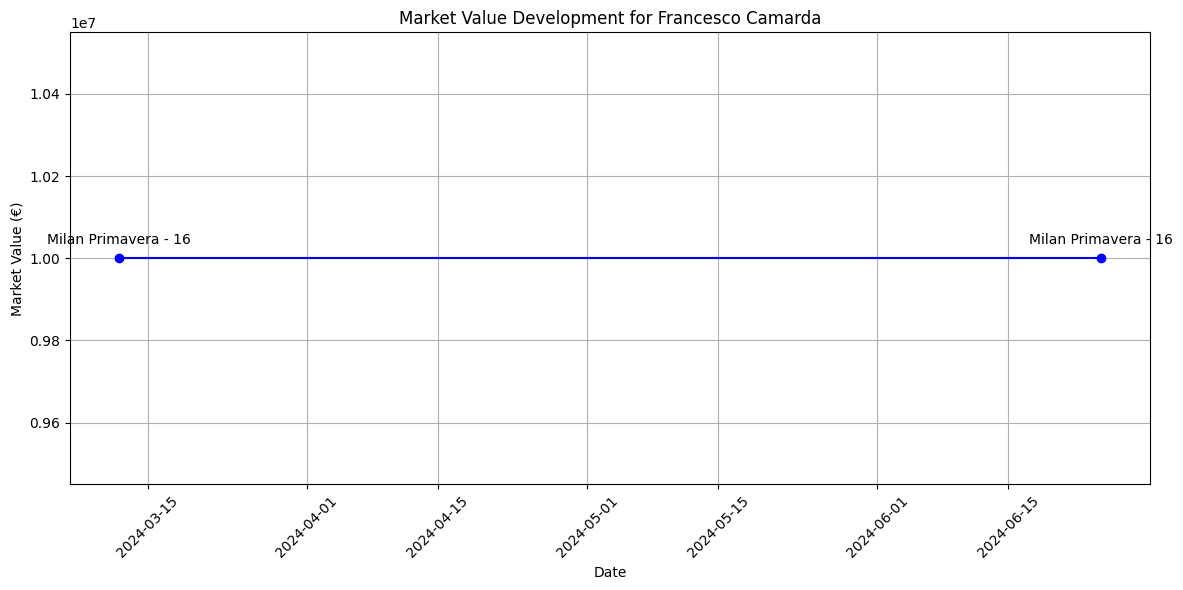

Current market value: €
Contract expiry date: nan
Player name: Julien Duranville


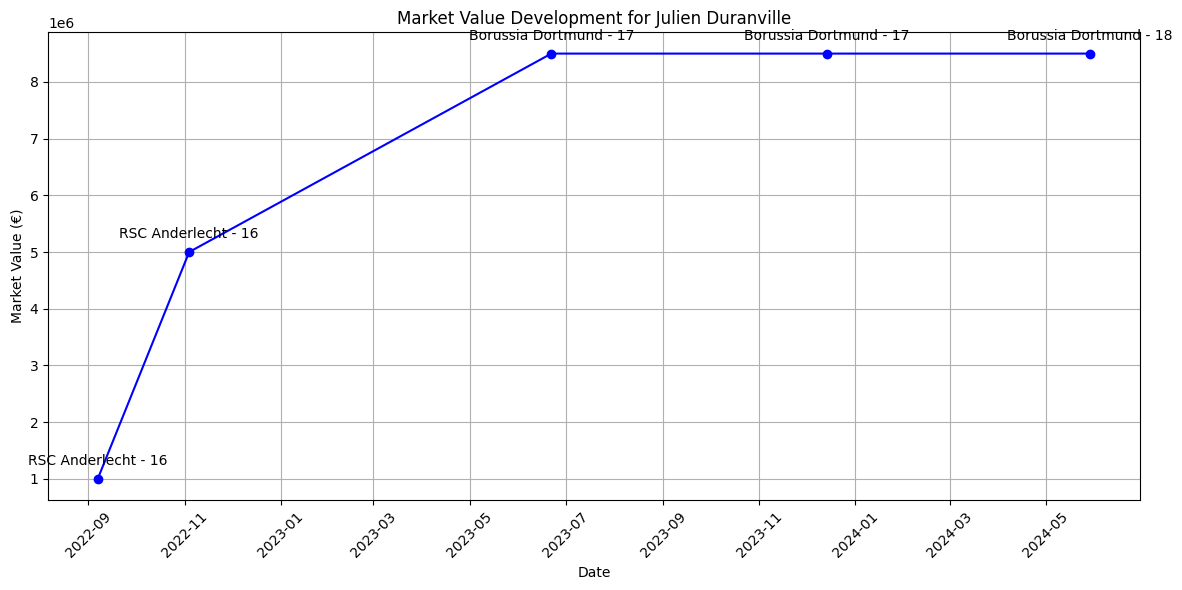

Current market value: €
Contract expiry date: nan
Player name: Franco Mastantuono


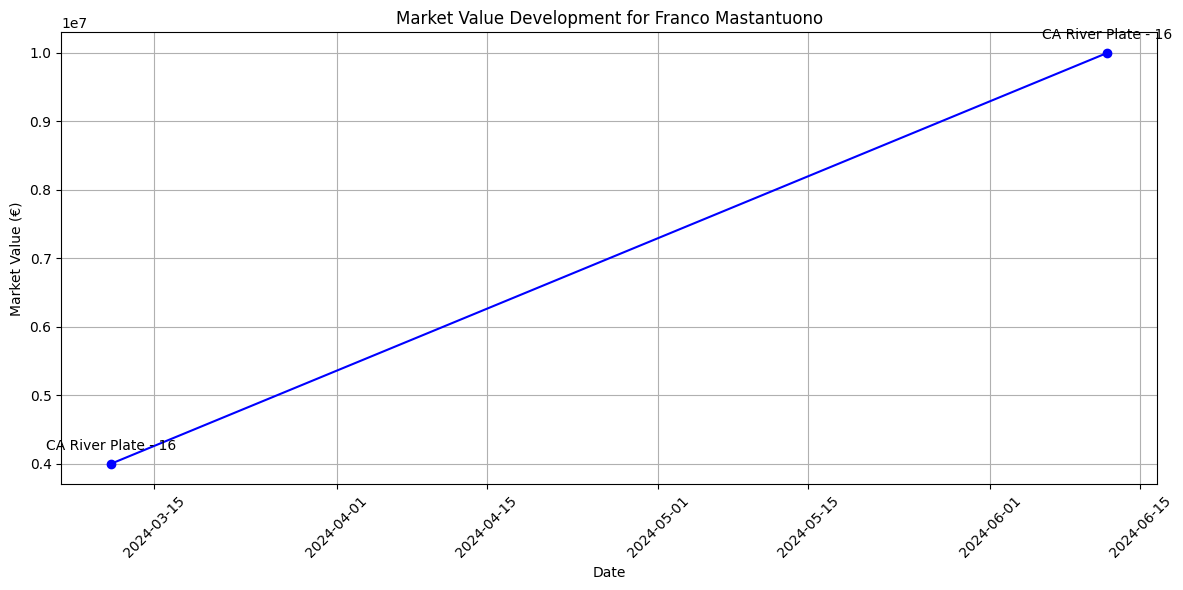

Current market value: €
Contract expiry date: nan
Player name: Jorthy Mokio


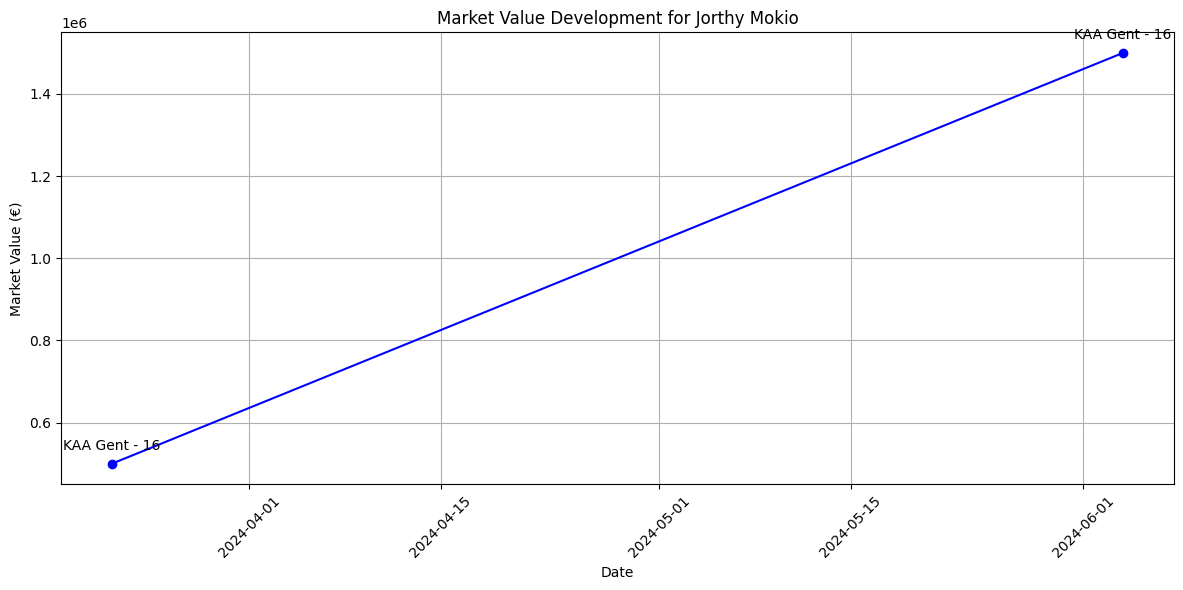

Current market value: €
Contract expiry date: nan
Player name: Sverre Nypan


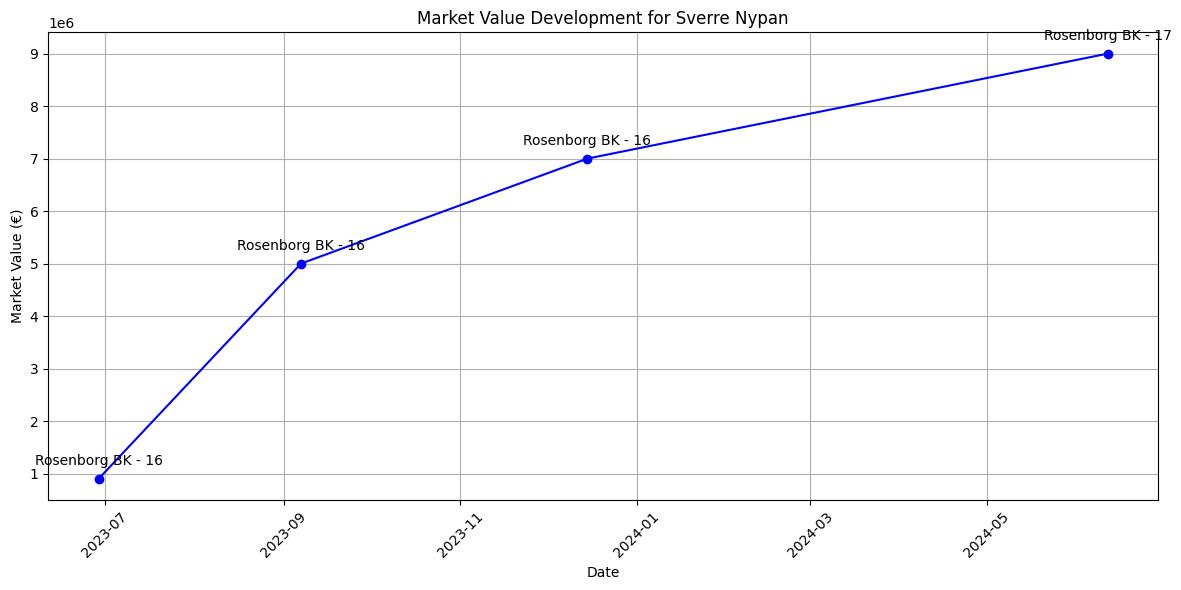

Current market value: €
Contract expiry date: nan
Player name: Rodrigo Mora


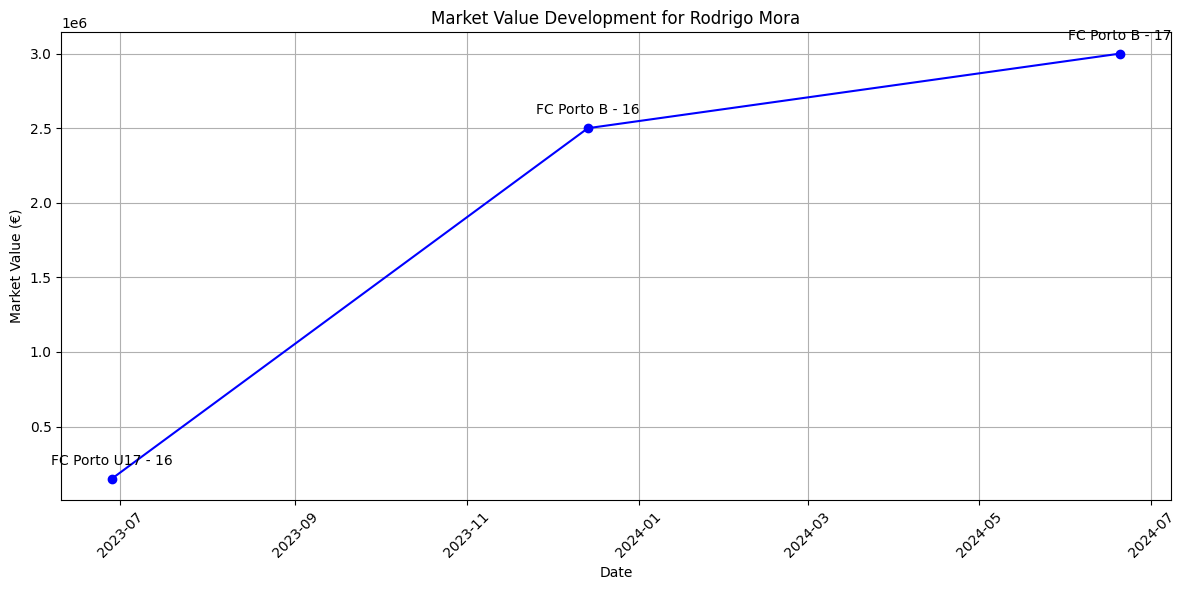

Current market value: €
Contract expiry date: nan
Player name: Lorran


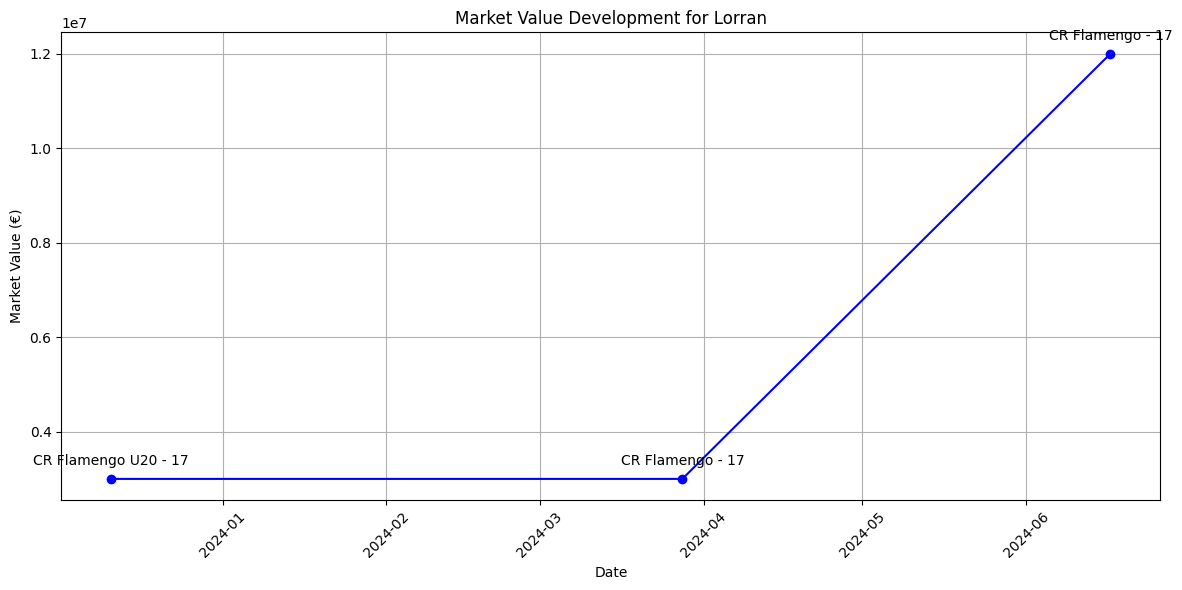

Current market value: €
Contract expiry date: nan
Player name: Assan Ouédraogo


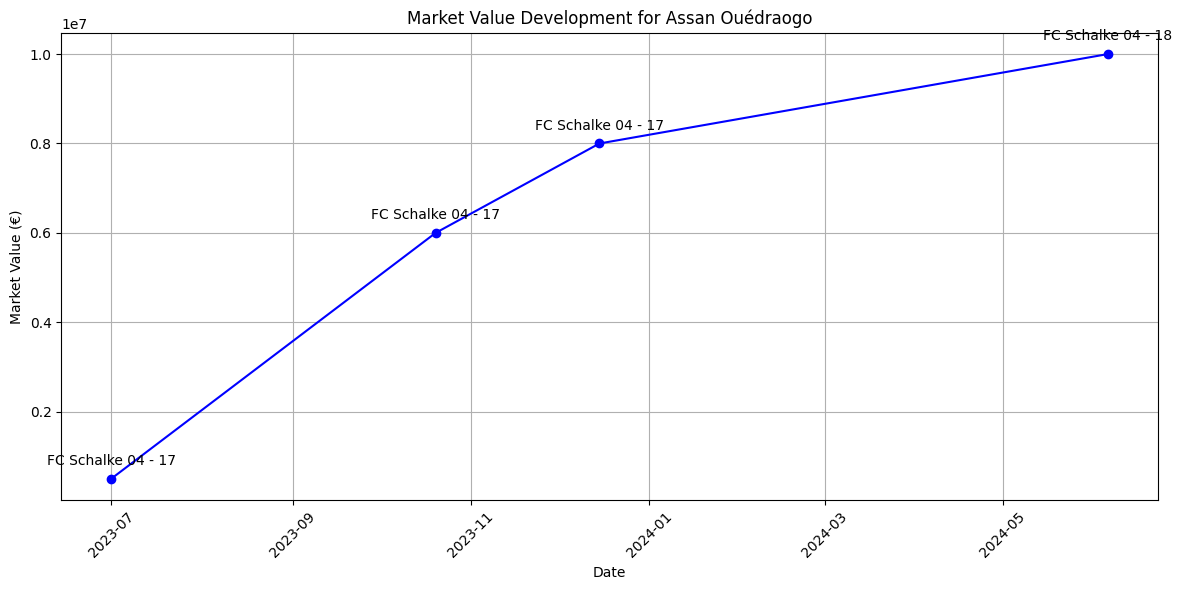

Current market value: €
Contract expiry date: nan


In [13]:
urls = [
    "https://www.transfermarkt.es/george-ilenikhena/profil/spieler/1004834",
    "https://www.transfermarkt.es/guillaume-restes/profil/spieler/912902",
    "https://www.transfermarkt.es/francesco-camarda/profil/spieler/1058368",
    "https://www.transfermarkt.es/julien-duranville/profil/spieler/819215",
    "https://www.transfermarkt.es/franco-mastantuono/profil/spieler/1057316",
    "https://www.transfermarkt.es/jorthy-mokio/profil/spieler/1105532",
    "https://www.transfermarkt.es/sverre-nypan/profil/spieler/911736",
    "https://www.transfermarkt.es/rodrigo-mora/profil/spieler/957653",
    "https://www.transfermarkt.es/lorran/profil/spieler/1009030",
    "https://www.transfermarkt.es/assan-ouedraogo/profil/spieler/897424"
]
for url in urls:
    get_player_info(url)

Player name: Harry Kane


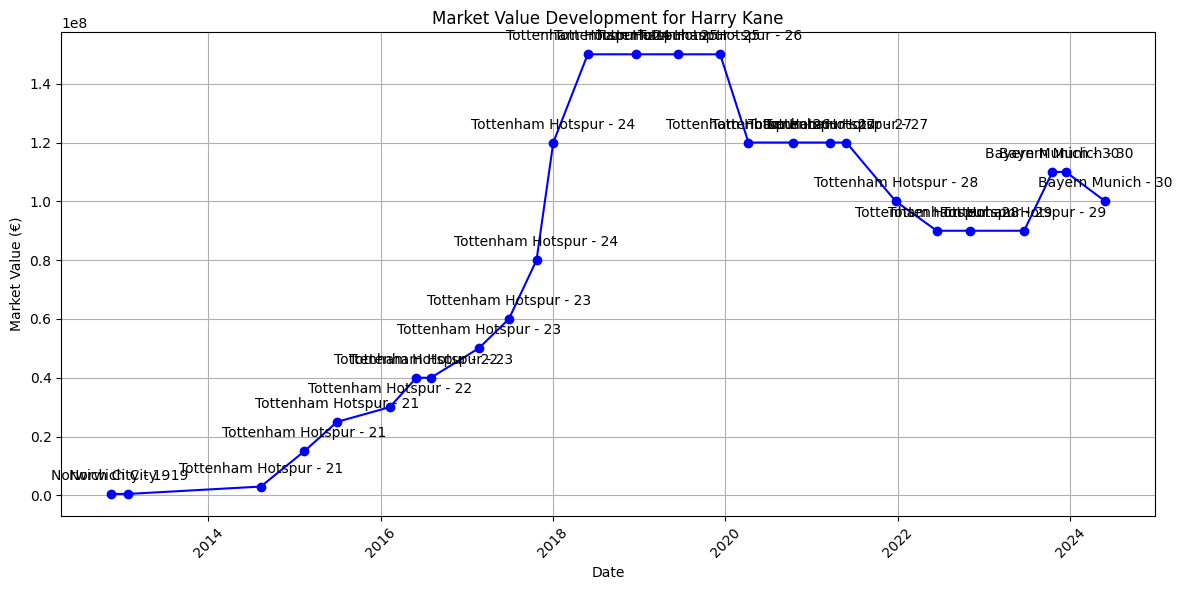

Current market value: €
Contract expiry date: nan


In [21]:
get_player_info('https://www.transfermarkt.es/harry-kane/profil/spieler/132098')